In [1]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime
import numpy as np

from chirpy.geometry import ImageGrid2D, TransducerArray2D, GeometryConfigurator
from chirpy.data.image_data import ImageData

from chirpy.optimization.operator.helmholtz import HelmholtzOperator
from chirpy.utils.progress import Progress, ProgressConfig

from scipy.io import savemat

In [2]:
DAT_PATH = Path("../../data/NumerialBreastPhantoms/Neg_07_Left/MergedPhantom.DAT")

In [3]:
# -------------------- Configuration (kept consistent with your script) --------------------
SAVE_DIR = Path("outputs")
SAVE_DIR.mkdir(exist_ok=True, parents=True)

# Phantom source
KWAVE_DIR = None
DAT_PATH = Path("../../data/NumerialBreastPhantoms/Neg_07_Left/MergedPhantom.DAT")
NX, NY, NZ = 616, 485, 719  # raw 3D (x,y,z) used to extract a single x-slice
SLICE_AXIS_X_INDEX = NX // 2  # take the middle X-plane

# Acoustic mapping
SOUND_SPEED_MAP = {
    0: 1500.0,  # background / water
    2: 1540.0,  # fibroglandular
    3: 1450.0,  # fat
    4: 1555.0,  # skin
    5: 1548.0,  # vessel
}
DENSITY_MAP = {0: 1000.0, 2: 1040.0, 3: 911.0, 4: 1100.0, 5: 945.0}

# Grids
nx_grid = ny_grid = 240
dx_grid = dy_grid = 1e-3  # 1 mm spacing
xmax = 120e-3 # 240*240 mm field with nx=480/dx=0.5mm(fine) or nx=240/dx=1mm(coarse)

# Array & physics
N_TX = 512
RADIUS_M = 110e-3
F0 = 1e6
C0_BG = 1500.0

# Time record policy
RECORD_PAD = 1.3

# Frequencies
freqs = np.arange(0.3, 1.35, 0.05) * 1e6

# Progress
progress = Progress(ProgressConfig(enabled=True, backend="tqdm", ncols=90))

# Neural operator packaging
PACK_TENSORS = True
use_gpu = False

# Filenames
OBS_NAME = SAVE_DIR / f"d_obs_{nx_grid}x{ny_grid}_{int(dx_grid * 1e3)}mm_0p3MHz_new_{N_TX}.npz"
INC_DIR = SAVE_DIR / "incident_fields"
SCAT_DIR = SAVE_DIR / "scattered_fields"
INC_DIR.mkdir(exist_ok=True, parents=True)
SCAT_DIR.mkdir(exist_ok=True, parents=True)
NEURAL_DIR = SAVE_DIR / "neural_operator_data"
NEURAL_DIR.mkdir(exist_ok=True, parents=True)

MAT_RESULTS = SAVE_DIR / "kWave_BreastCT_WaveformInversionResults.mat"
NEURAL_NPZ = NEURAL_DIR / "neural_operator_training_data.npz"


# -------------------- Utilities --------------------
def log(msg: str) -> None:
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {msg}")


def load_labels_slice(
    dat_path: Path, shape_xyz: tuple[int, int, int], x_index: int
) -> np.ndarray:
    """Load 3D uint8 labels in Fortran order and return one x-slice as (Ny, Nz)."""
    NX_, NY_, NZ_ = shape_xyz
    with open(dat_path, "rb") as f:
        raw = np.fromfile(f, dtype=np.uint8)
    raw = raw.reshape((NX_, NY_, NZ_), order="F")
    return raw[x_index, :, :]  # (Ny, Nz)


def labels_to_maps(labels_2d: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Map integer labels → sound speed & density arrays."""
    ss = np.zeros_like(labels_2d, dtype=np.float32)
    rho = np.zeros_like(labels_2d, dtype=np.float32)
    for lab, c in SOUND_SPEED_MAP.items():
        mask = labels_2d == lab
        ss[mask] = float(c)
        rho[mask] = float(DENSITY_MAP.get(lab, 1000.0))
    ss[ss <= 0] = SOUND_SPEED_MAP[3]  # default unmapped to fat
    return ss, rho


def pad_to_square(arr: np.ndarray, target: int, bg: float = 1500.0) -> np.ndarray:
    """
    Center-pad a 2D array to (target, target) using constant background value.
    """
    ny, nx = arr.shape
    if target < max(ny, nx):
        raise ValueError(f"target={target} < original size {(ny, nx)}")

    # compute padding sizes
    pad_y = target - ny
    pad_x = target - nx

    pad_top = pad_y // 2
    pad_bottom = pad_y - pad_top
    pad_left = pad_x // 2
    pad_right = pad_x - pad_left

    arr_pad = np.pad(
        arr,
        ((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=float(bg),
    )
    return arr_pad

[19:30:17] Loading phantom DAT and building sound-speed slice...


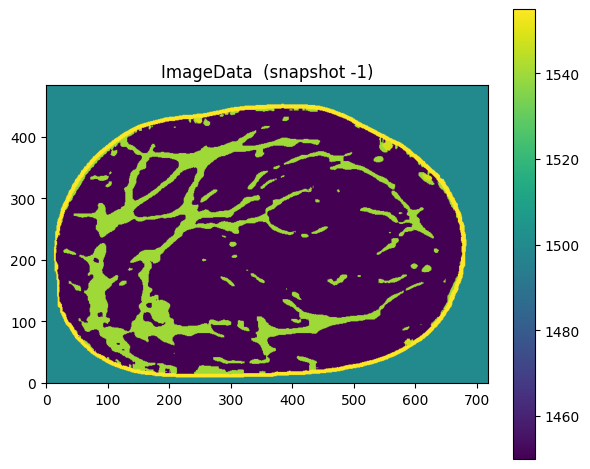

<Axes: title={'center': 'ImageData  (snapshot -1)'}>

In [4]:
log("Loading phantom DAT and building sound-speed slice...")

labels = load_labels_slice(DAT_PATH, (NX, NY, NZ), SLICE_AXIS_X_INDEX)  # (Ny, Nz)
c_raw, _rho_raw = labels_to_maps(labels)  # (Ny, Nz)
ImageData(c_raw).show(cmap="viridis")

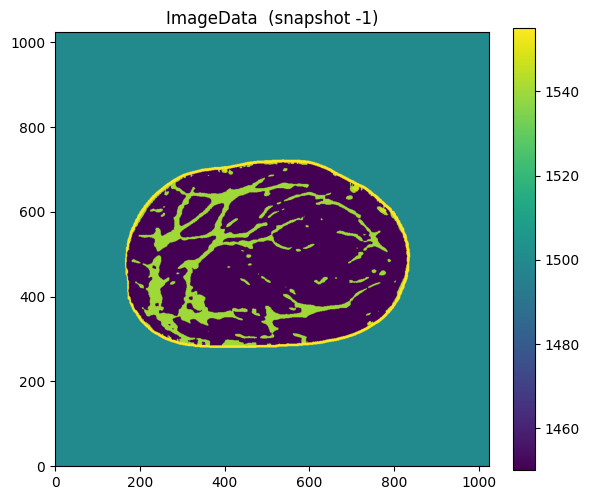

<Axes: title={'center': 'ImageData  (snapshot -1)'}>

In [5]:
c_pad = pad_to_square(c_raw, target=1024, bg=1500.0)
ImageData(c_pad).show(cmap="viridis")

In [6]:
# (2) The original Leili's process: Downsample to 120×120 then pad to 180×180
# log("Downsampling to 120×120 and padding to 180×180...")
# grid_core = ImageGrid2D(nx=120, ny=120, dx=1e-3, dy=1e-3)
# c_core = ImageData(c_raw).downsample_to(new_grid=grid_core)
# c_core.show(cmap="viridis")
# c_pad = pad_to_square(c_core.array, target=180, bg=1500.0)
# c_true = ImageData(c_pad)
# c_true.show(cmap="viridis")

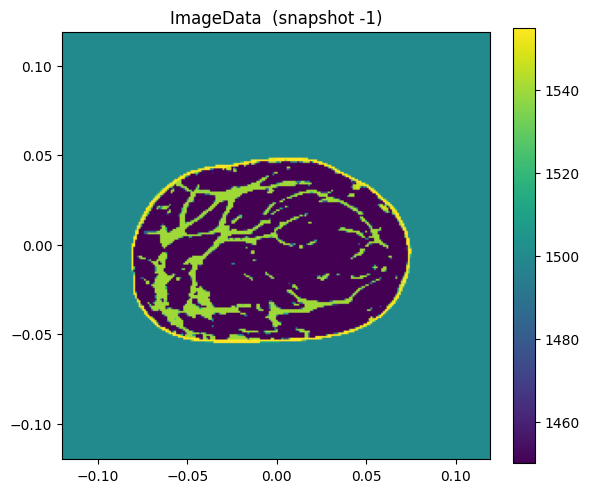

<Axes: title={'center': 'ImageData  (snapshot -1)'}>

In [7]:
grid = ImageGrid2D(nx=nx_grid, dx=dx_grid)
c_true = ImageData(c_pad).downsample_to(new_grid=grid)
c_true.show(cmap="viridis")

[19:30:21] Building 512-elt ring


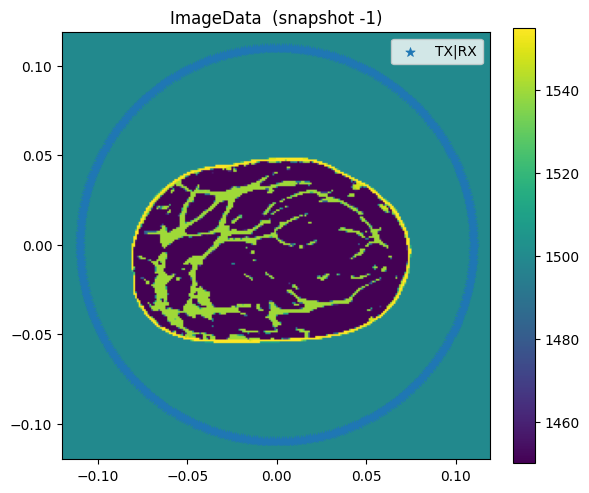

<Axes: title={'center': 'ImageData  (snapshot -1)'}>

In [8]:
log("Building 512-elt ring")
tx_array = TransducerArray2D.from_ring_array_2D(r=RADIUS_M, grid=grid, n=N_TX)
geom_view = ImageData(array=c_true.array, grid=grid,tx_array=tx_array)
geom_view.show(cmap="viridis")

In [11]:
geom_config = GeometryConfigurator(grid, tx_array)
print("Freqs: ", freqs)

Freqs:  [ 300000.  350000.  400000.  450000.  500000.  550000.  600000.  650000.
  700000.  750000.  800000.  850000.  900000.  950000. 1000000. 1050000.
 1100000. 1150000. 1200000. 1250000. 1300000.]


In [45]:
op = HelmholtzOperator(
    geom_config = geom_config,
    freq=freqs[0],
    sign_conv=-1,
    pml_alpha=10.0,
    pml_size=9.0e-3,
    use_gpu=use_gpu,
    progress=progress
)

In [46]:
# ---- Incident fields (homogeneous c0) ----
slow_hom = np.full(
    (grid.ny, grid.nx), (1.0 / C0_BG), dtype=np.complex128
)
_ = op.forward(slow_hom)  # caches wavefield for all sources
incident_fields = op._cache.WF.copy()  # (ny, nx, n_tx)

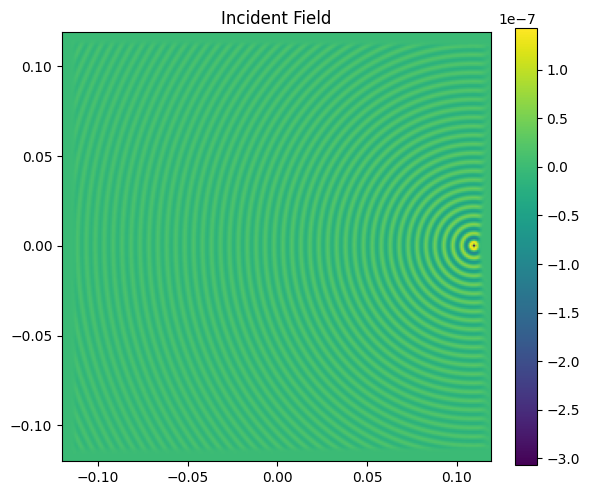

<Axes: title={'center': 'Incident Field'}>

In [47]:
# view one incident field
i = 0
ImageData(incident_fields[:, :, i], grid=grid).show(cmap="viridis", title="Incident Field")

In [48]:
# ---- Total fields in heterogeneous medium → scattered = total - incident ----
slow_het = (1.0 / c_true.array).astype(np.complex128)  # no attenuation
_ = op.forward(slow_het)
total_fields = op._cache.WF.copy()
scattered_fields = total_fields - incident_fields

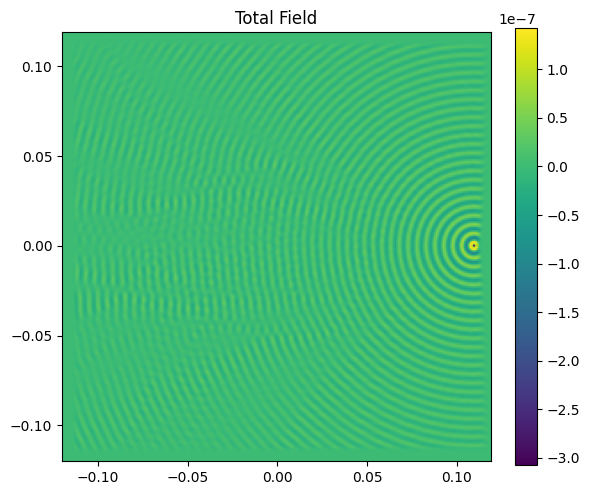

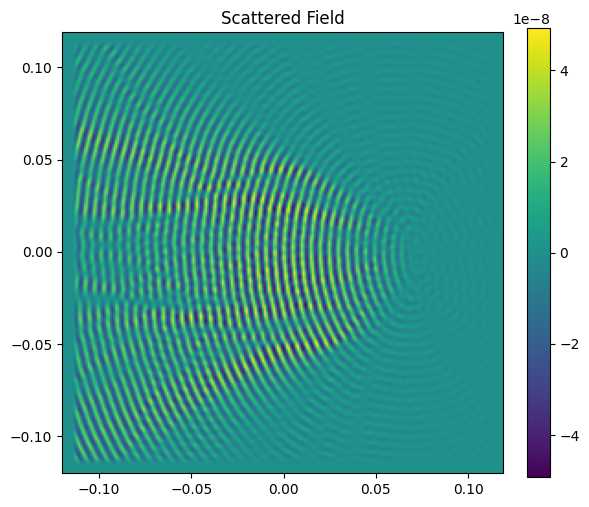

<Axes: title={'center': 'Scattered Field'}>

In [49]:
i = 0
ImageData(total_fields[:, :, i], grid=grid).show(cmap="viridis", title="Total Field")
ImageData(scattered_fields[:, :, i], grid=grid).show(cmap="viridis", title="Scattered Field")